# Stock Price Forecasting using Time Series (Indian )


## Problem Statement

**The main problem addressed in this project is predicting future stock prices and identifying potential profit or loss opportunities. Stock prices are highly dynamic and influenced by past trends, making it difficult for investors to decide the right time to invest.**

**This project aims to analyze historical stock data and forecast future prices to support better decision-making and help users identify favorable investment opportunities.**

# Objective

-  predict future stock prices using historical data
-  analyze trends, volatility, and time-based patterns
-  identify potential profit and loss opportunities
-  help users determine the best time to invest
-  apply and compare different forecasting models
-  evaluate model performance using RMSE
-  compare results across multiple stocks (RELIANCE, INFY)

## About the data

| Column    | Description                                |
|-----------|--------------------------------------------|
| Date      | Trading date                               |
| Open      | Price at market open                       |
| High      | Highest price of the day                   |
| Low       | Lowest price of the day                    |
| Close     | Price at market close                      |
| Adj Close | Adjusted close (includes dividends/splits) |
| Volume    | Number of shares traded                    |

# Target Variable

**The target variable in this project is the "Close" price.**

**The closing price represents the final trading value of the stock for each day and is widely used for forecasting and investment analysis**

## 1.Import Libraries

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import MSTL
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import pickle
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import streamlit as st
import joblib

# 2.Load DataSet

In [117]:

stocks = ["RELIANCE.NS", "INFY.NS"] #"TCS.NS"]

data = yf.download(stocks, period="3y", threads=False)
data = data.stack(level=1).reset_index()

data.columns = ["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]

[*********************100%***********************]  2 of 2 completed
C:\Users\shafe\AppData\Local\Temp\ipykernel_12528\2284244231.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(level=1).reset_index()


## Preview of data

In [119]:
data.head()

,Date,Ticker,Open,High,Low,Close,Volume
0,2023-05-08,INFY.NS,1160.716553,1165.027119,1151.178404,1157.827579,5260842
1,2023-05-08,RELIANCE.NS,1128.414062,1133.777882,1115.746261,1118.416700,9153782
2,2023-05-09,INFY.NS,1165.393799,1166.586109,1156.222524,1161.083345,4969897
3,2023-05-09,RELIANCE.NS,1131.906128,1135.215801,1124.465220,1129.829039,6464721
4,2023-05-10,INFY.NS,1158.561279,1170.621528,1154.801079,1170.621528,6515734


## Inspect structure

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1486 entries, 0 to 1485
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1486 non-null   datetime64[ns]
 1   Ticker  1486 non-null   object        
 2   Open    1486 non-null   float64       
 3   High    1486 non-null   float64       
 4   Low     1486 non-null   float64       
 5   Close   1486 non-null   float64       
 6   Volume  1486 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 81.4+ KB


## Missing Values

In [39]:
data.isnull().sum()

Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [40]:
data.duplicated().sum()

np.int64(0)

## statical summary

In [41]:
data.describe()

,Date,Open,High,Low,Close,Volume
count,1486,1486.000000,1486.000000,1486.000000,1486.000000,1.486000e+03
mean,2024-11-05 08:49:05.895020288,1432.261732,1445.177862,1419.619265,1432.493141,1.028694e+07
min,2023-05-08 00:00:00,1105.070923,1116.567877,1101.993723,1111.067256,0.000000e+00
25%,2024-02-05 06:00:00,1294.447540,1303.805027,1281.395533,1293.521661,6.105764e+06
50%,2024-11-06 00:00:00,1419.151978,1431.850037,1406.990136,1420.605559,8.703976e+06
75%,2025-08-05 18:00:00,1528.771301,1542.875000,1514.846834,1529.606691,1.261188e+07
max,2026-05-08 00:00:00,1942.221191,1948.777171,1920.756459,1938.093361,5.708188e+07
std,NaN,183.470796,185.746808,181.198276,183.665956,6.362996e+06


## Data Type check

In [42]:
data.dtypes


Date      datetime64[ns]
Ticker            object
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

## Univariate and bivariate analysis

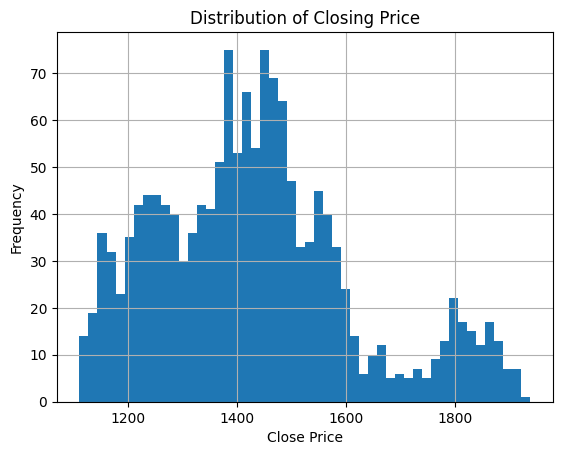

In [43]:
data['Close'].hist(bins=50)
plt.title("Distribution of Closing Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

- Most closing prices are between 1350–1550.
- The stock shows moderate volatility.
- Distribution is slightly right-skewed.
- Few prices occurred above 1800.

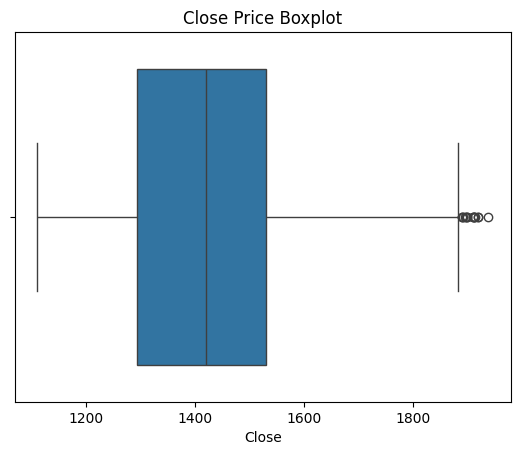

In [44]:
sns.boxplot(x=data["Close"])
plt.title("Close Price Boxplot")
plt.show()


- Median closing price is around 1400.
- Most closing prices are between 1250–1550.
- Few high-value outliers are present near 1900.
- Distribution is slightly right-skewed.

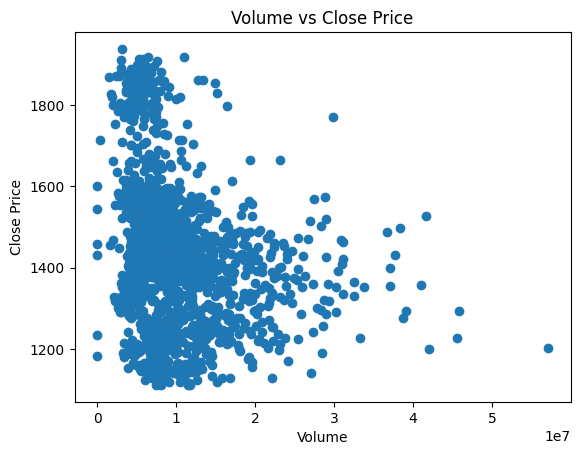

In [45]:
plt.scatter(data['Volume'], data['Close'])
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.title("Volume vs Close Price")
plt.show()

- There is no strong relationship between trading volume and closing price.

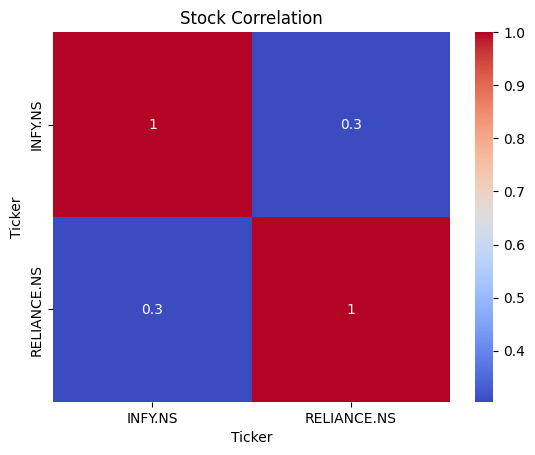

In [46]:
pivot = data.pivot(index="Date", columns="Ticker", values="Close")

sns.heatmap(pivot.corr(), annot=True, cmap="coolwarm")
plt.title("Stock Correlation")
plt.show()

- INFY.NS and RELIANCE.NS show a weak positive correlation (0.3).
- Both stocks are not strongly related in price movement.
- Diagonal value 1 indicates perfect self-correlation.
- The stocks may behave independently under different market conditions.

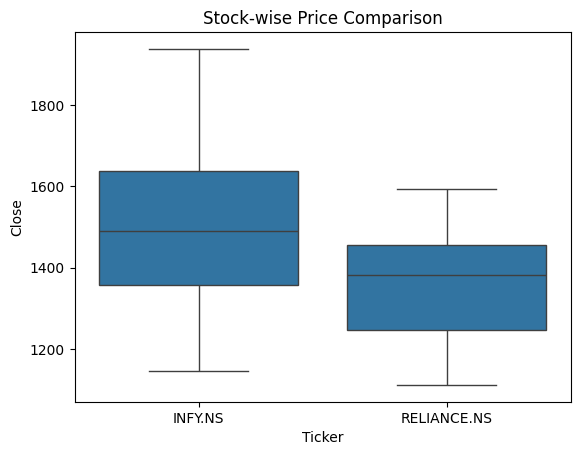

In [47]:
sns.boxplot(x='Ticker', y='Close', data=data)
plt.title("Stock-wise Price Comparison")
plt.show()

- INFY.NS has a higher median closing price than RELIANCE.NS.
- INFY.NS shows greater price volatility compared to RELIANCE.NS.

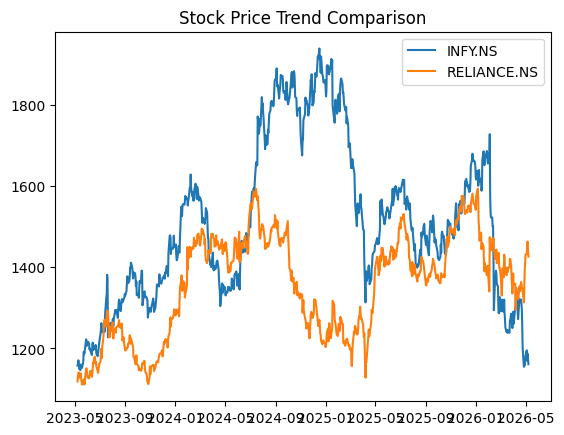

In [48]:
for stock in data['Ticker'].unique():
    subset = data[data['Ticker'] == stock]
    plt.plot(subset['Date'], subset['Close'], label=stock)

plt.legend()
plt.title("Stock Price Trend Comparison")
plt.show()

- INFY.NS shows larger price fluctuations than RELIANCE.NS.
- Both stocks show changing trends over time with periods of rise and fall.



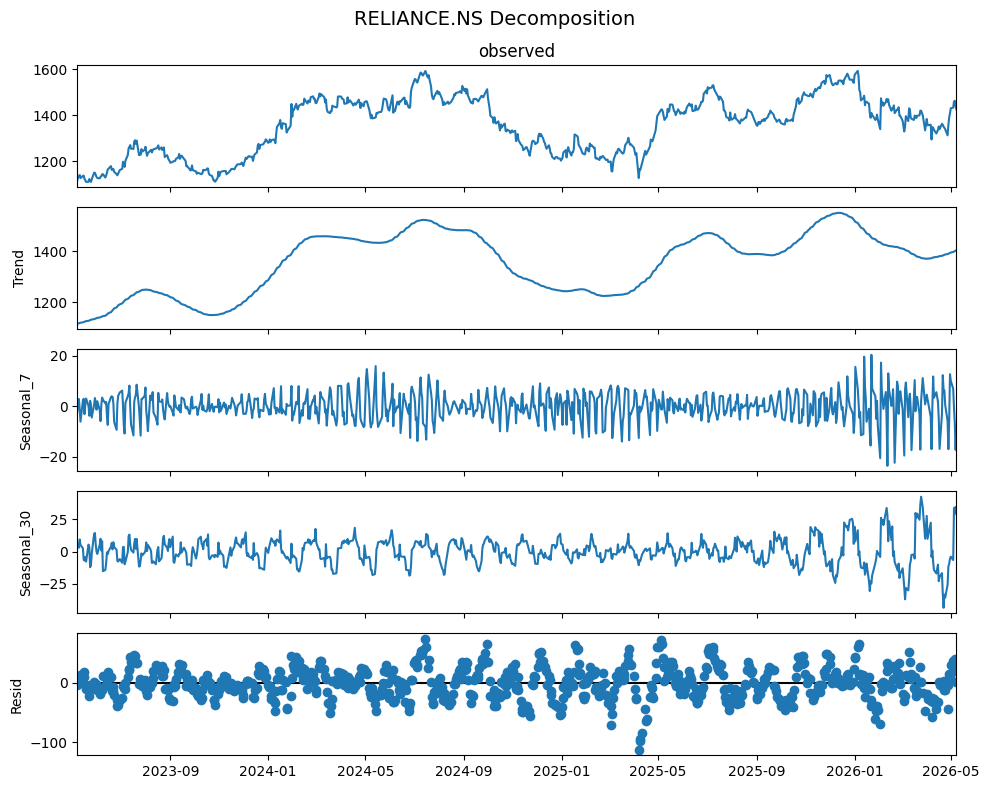

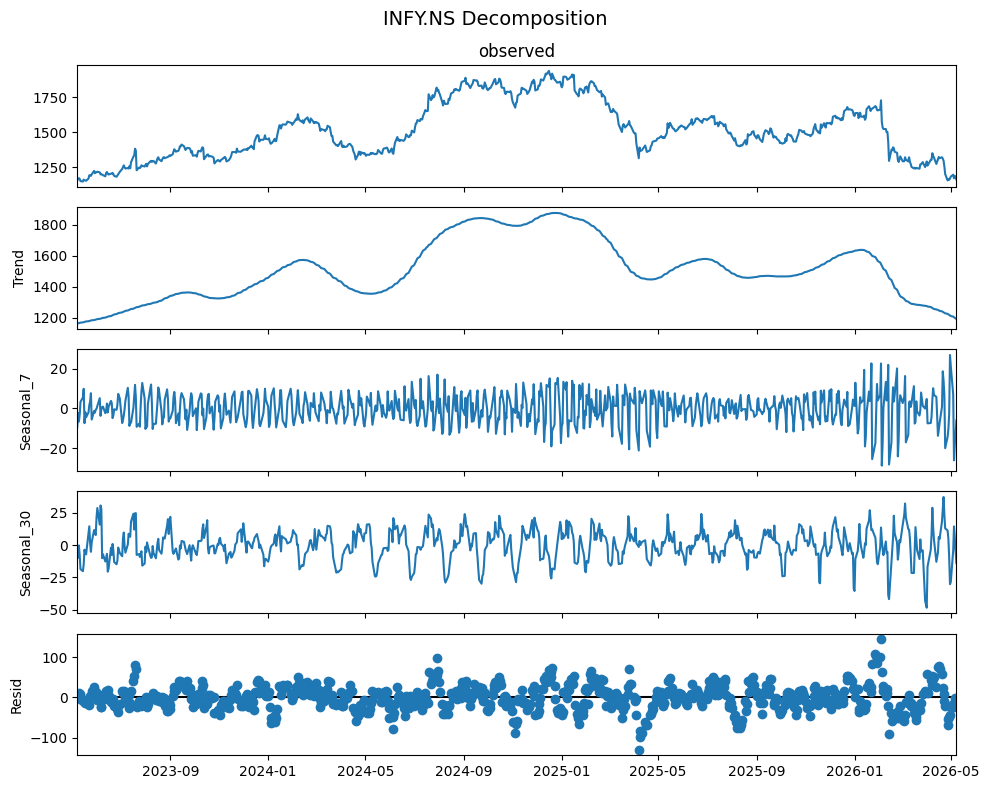

In [49]:
for stock in stocks:
    
    df = data[data["Ticker"] == stock].copy()
    df.set_index("Date", inplace=True)

    mstl = MSTL(df["Close"], periods=(7, 30))
    result = mstl.fit()

    fig = result.plot()
    fig.set_size_inches(10, 8)

    plt.suptitle(f"{stock} Decomposition", fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualization Insights

- The histogram shows that stock prices are not normally distributed and vary significantly across different stocks.

- The boxplot indicates the presence of outliers and differences in price ranges among stocks, with TCS having a higher price range compared to others.

- The scatter plot between volume and closing price shows a weak relationship, indicating that trading volume does not directly determine price levels.

- The correlation heatmap reveals strong relationships among stock prices, suggesting similar market movement patterns.

- The stock-wise comparison highlights differences in volatility and price levels across companies.
## Time Series Insight
- The time series plot shows that stock prices exhibit clear trends over time along with fluctuations. This confirms that the data is non-stationary and influenced by past values, making it suitable for time series forecasting models.
  
## Decomposition Section
MSTL decomposition was used to analyze multiple seasonal patterns in stock prices.

The trend component shows the overall direction of stock movement. The seasonal components (weekly and monthly) are relatively weak, indicating that stock prices do not follow strong periodic patterns. The residual component captures irregular fluctuations and market noise.

This confirms that stock prices are mainly driven by trend and randomness rather than fixed seasonal cycles.

# Data cleaning and preprocessing

In [50]:
(data[['Open','High','Low','Close','Volume']] <= 0).sum()

Open      0
High      0
Low       0
Close     0
Volume    6
dtype: int64

In [51]:
data.isnull().sum()

Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

# ONE HOT ENCODING

In [52]:
"""def one_hotencode(df,column_name='Ticker'):
    df=df.copy()
    df[column_name]=df[column_name].astype("category")
    df=pd.get_dummies(df,columns=[column_name],dtype='int')
    return df"""
c'''lass OneHotEncoderCustom(BaseEstimator, TransformerMixin):
    def __init__(self, column_name="Ticker"):
        self.column_name = column_name

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column_name] = X[self.column_name].astype("category")
        X = pd.get_dummies(X, columns=[self.column_name], dtype="int")
        return X

_IncompleteInputError: incomplete input (3702741240.py, line 6)

# MINMAX SCALER

In [ ]:
'''def minmax_scaler(df,target_column):
    df=df.copy()
    scaler=MinMaxScaler()
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    numeric_cols = numeric_cols.drop(target_column)
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    return df'''
    
class MinMaxScalerCustom(BaseEstimator, TransformerMixin):
    def __init__(self, target_column):
        self.target_column = target_column
        self.scaler = MinMaxScaler()

    def fit(self, X, y=None):
        numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
        self.numeric_cols = numeric_cols.drop(self.target_column)
        self.scaler.fit(X[self.numeric_cols])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.numeric_cols] = self.scaler.transform(X[self.numeric_cols])
        return X

# Featue Engineering

In [53]:
def feature_engineering(data,ticker_cols):
    
    stock = data[data["Ticker"] == ticker_cols].copy()        #filter only one stock one by one
   
    stock['Date']=pd.to_datetime(stock['Date'])       # its convert date formate and sort it 
    stock=stock.sort_values('Date')

    stock['price_Range']=stock['High']-stock['Low']
    stock['price_change']=stock['Close']-stock['Open']       # price based Feature engineering
    stock["Return"] = stock["Close"].pct_change()    



    stock["MA_7"] = stock["Close"].rolling(7).mean()

    stock["MA_30"] = stock["Close"].rolling(30).mean()

    stock["EMA_7"] = stock["Close"].ewm(span=7).mean()                 # Rolling / Moving Features

    stock["EMA_30"] = stock["Close"].ewm(span=30).mean()

    stock["Rolling_STD"] = stock["Close"].rolling(7).std()




    for i in range(1,8):
        stock[f"Lag_{i}"]=stock["Close"].shift(i)                        # its using lag feature for like previous


    stock['Day']=stock['Date'].dt.day
    stock['Month']=stock['Date'].dt.month
    stock['weakday']=stock['Date'].dt.weekday

    stock['Target']=stock['Close'].pct_change().shift(-1)            # Percentage change between current value and previous value


    stock['Return_Lag1']=stock['Return'].shift(1)
    stock['Return_Lag5']=stock['Return'].shift(5)                    # Move column values up or down by a number of rows.
    



    stock["MA_5_Ratio"] = (stock["Close"].rolling(5).mean() / stock["Close"])
    stock["MA_20_Ratio"] = (stock["Close"].rolling(20).mean() / stock["Close"])          #Compares a rolling average value with the current value.
        
   
    return stock



In [54]:
ticker_cols = data["Ticker"].unique()

results = {}

for col in ticker_cols:
    results[col] = feature_engineering(data, col)

In [55]:
data = pd.concat(
    results.values(),
    ignore_index=True
)

# Missing Value Handling

In [61]:
"""cols_to_fill = ["MA_7", "MA_30", "Rolling_STD", "Lag_1", "Lag_2", "Lag_7", "Returns"]
def fill_na_groupwise_mean(data, cols, group_col="Ticker"):
   
    for col in cols:
        data[col] = data.groupby(group_col)[col].transform(lambda x: x.fillna(x.mean()))
    
    return data"""
class MissingValueHandler(BaseEstimator, TransformerMixin):
    def __init__(self, cols, group_col="Ticker"):
        self.cols = cols
        self.group_col = group_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            X[col] = X.groupby(self.group_col)[col].transform(
                lambda x: x.fillna(x.mean())
            )
        return X

In [62]:
cols_to_fill = [
    'Return','MA_7','MA_30','EMA_7','EMA_30',
    'Rolling_STD','Lag_1','Lag_2','Lag_3',
    'Lag_4','Lag_5','Lag_6','Lag_7',
    'Target','Return_Lag1','Return_Lag5',
    'MA_5_Ratio','MA_20_Ratio'
]

pipeline = Pipeline([
    #('feature_engineer',feature_engineering(data,ticker_cols)),
    ("missing", MissingValueHandler(cols=cols_to_fill)),
    #("encoding", OneHotEncoderCustom(column_name="Ticker")),
    ("scaling", MinMaxScalerCustom(target_column="Close"))
])

In [63]:
data = pipeline.fit_transform(data)

# Preprocessing Pipeline
### What I do
Build a pipeline to clean data, handle missing values, create features, and scale the dataset.

### Why I do this
To ensure consistent and automated preprocessing before model training.

### Steps
#### 1. missing value handled
Fill missing values using group-wise mean or suitable methods.
### 2. Feature Scaling
Normalize feature values using MinMaxScaler for better model performance.

In [64]:
data.isnull().sum()

Date            0
Ticker          0
Open            0
High            0
Low             0
Close           0
Volume          0
price_Range     0
price_change    0
Return          0
MA_7            0
MA_30           0
EMA_7           0
EMA_30          0
Rolling_STD     0
Lag_1           0
Lag_2           0
Lag_3           0
Lag_4           0
Lag_5           0
Lag_6           0
Lag_7           0
Day             0
Month           0
weakday         0
Target          0
Return_Lag1     0
Return_Lag5     0
MA_5_Ratio      0
MA_20_Ratio     0
dtype: int64

In [65]:

data.columns

Index(['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume',
       'price_Range', 'price_change', 'Return', 'MA_7', 'MA_30', 'EMA_7',
       'EMA_30', 'Rolling_STD', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5',
       'Lag_6', 'Lag_7', 'Day', 'Month', 'weakday', 'Target', 'Return_Lag1',
       'Return_Lag5', 'MA_5_Ratio', 'MA_20_Ratio'],
      dtype='object')

In [73]:
data

,Date,Ticker,Open,High,Low,Close,Volume,price_Range,price_change,Return,...,Lag_6,Lag_7,Day,Month,weakday,Target,Return_Lag1,Return_Lag5,MA_5_Ratio,MA_20_Ratio
0,2023-05-08,INFY.NS,0.066470,0.058229,0.060072,1157.827457,0.092163,0.100549,0.450636,0.507077,...,0.485950,0.486518,8,5,0,0.520287,0.507146,0.507197,0.328170,0.333543
1,2023-05-09,INFY.NS,0.072057,0.060103,0.066232,1161.083223,0.087066,0.075245,0.443049,0.520287,...,0.485950,0.486518,9,5,1,0.546976,0.507146,0.507197,0.328170,0.333543
2,2023-05-10,INFY.NS,0.063896,0.064952,0.064497,1170.621528,0.114147,0.114865,0.530429,0.546976,...,0.485950,0.486518,10,5,2,0.482596,0.520287,0.507197,0.328170,0.333543
3,2023-05-11,INFY.NS,0.056063,0.064401,0.057664,1164.981284,0.120677,0.152155,0.535324,0.482596,...,0.485950,0.486518,11,5,3,0.440675,0.546976,0.507197,0.328170,0.333543
4,2023-05-12,INFY.NS,0.044121,0.042470,0.041982,1149.481568,0.145269,0.112867,0.505953,0.440675,...,0.485950,0.486518,12,5,4,0.492799,0.482596,0.507197,0.382016,0.333543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1481,2026-05-04,RELIANCE.NS,0.427676,0.421567,0.404765,1433.400024,0.421074,0.246859,0.307530,0.515373,...,0.276814,0.284069,4,5,0,0.598064,0.582824,0.406865,0.214277,0.177287
1482,2026-05-05,RELIANCE.NS,0.428273,0.428777,0.425039,1460.000000,0.412449,0.169897,0.446841,0.598064,...,0.244167,0.276814,5,5,1,0.516547,0.515373,0.675694,0.192512,0.137949
1483,2026-05-06,RELIANCE.NS,0.397574,0.428657,0.397559,1463.000000,0.249147,0.332534,0.600030,0.516547,...,0.298579,0.244167,6,5,2,0.424687,0.598064,0.630072,0.235720,0.148877
1484,2026-05-07,RELIANCE.NS,0.395543,0.400058,0.400979,1438.800049,0.347166,0.139402,0.479935,0.424687,...,0.339690,0.298579,7,5,3,0.462451,0.516547,0.566724,0.351745,0.202736


In [79]:
def arima_per_stock(data, ticker_name):
    
    stock = data[data["Ticker"] == ticker_name].copy()


    stock["Date"] = pd.to_datetime(stock["Date"])
    stock = stock.sort_values("Date")
    stock.set_index("Date", inplace=True)

    series = stock["Close"]

    # Train-test split
    train_size = int(len(series) * 0.8)
    train = series[:train_size]
    test = series[train_size:]

    # Model
    model = auto_arima(train, seasonal=False, trace=False)
    pred = model.predict(n_periods=len(test))

    # Accuracy
    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))
    r2 = r2_score(test,pred)


    return {
        "test": test,
        "pred": pred,
        "mae": mae,
        "rmse": rmse,
        "r2_score":r2
    }

In [80]:
ticker_cols = [
    "RELIANCE.NS",
    "INFY.NS"
]

results = {}

for col in ticker_cols:
    results[col] = arima_per_stock(data, col)

C:\Users\shafe\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\shafe\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\shafe\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\shafe\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the n

## ARIMA 

In [81]:

for col in ticker_cols:
    print(f"\n {col}")
    print("MAE :", results[col]["mae"])
    print("RMSE:", results[col]["rmse"])
    print('r2_score:',results[col]['r2_score'])


 RELIANCE.NS
MAE : 77.79464496382131
RMSE: 99.05407879008644
r2_score: -0.7648732473460349

 INFY.NS
MAE : 138.90505633676773
RMSE: 157.21799897148713
r2_score: -0.008572261161997163


In [92]:
def xgb_per_stock(data, ticker_name):

    # Filter one stock
    stock = data[data["Ticker"] == ticker_name].copy()

    # Sort date
    stock["Date"] = pd.to_datetime(stock["Date"])
    stock = stock.sort_values("Date")

    # Features and target
    X = stock.drop(columns=["Close", "Date", "Ticker"])
    y = stock["Close"]

    # Remove NaN rows
    X = X.dropna()
    y = y.loc[X.index]

    # Train-test split
    split = int(len(X) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # Model
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return {
        "test": y_test,
        "pred": pred,
        "mae": mae,
        "rmse": rmse,
        "r2_score": r2
    }

In [93]:
ticker_cols = [
    "RELIANCE.NS",
    "INFY.NS"
]

results = {}

for col in ticker_cols:
    results[col] = xgb_per_stock(data, col)

## XG BOOST

In [96]:
for col in ticker_cols:
    print(f"\n {col}")
    print("MAE :", results[col]["mae"])
    print("RMSE:", results[col]["rmse"])
    print("R2  :", results[col]["r2_score"])



 RELIANCE.NS
MAE : 5.889813928796141
RMSE: 7.886365458673417
R2  : 0.9888127693911547

 INFY.NS
MAE : 7.8917976722830865
RMSE: 10.712335300932867
R2  : 0.9953175752525963


## RANDOM FOREST

In [99]:

def rf_per_stock_improved(data,ticker_name):
    # 1. Filter and sort by date
    stock = data[data["Ticker"] == ticker_name].copy()
    stock["Date"] = pd.to_datetime(stock["Date"])
    stock = stock.sort_values("Date")

     # X = stock.drop(columns=["Close", "Date", "Target", ticker_col])
     # y = stock["Target"]
    X = stock.drop(columns=["Close", "Date","Ticker"])
    y = stock["Close"]

    # 4. Train-Test split (time-based)
    split = int(len(stock) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # 5. Model & Grid Search Configuration
    model = RandomForestRegressor(random_state=42)
    
    # Tuned for stability to prevent overfitting on stock noise
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [5, 8],
        'min_samples_leaf': [2, 5],
        'max_features': ['sqrt'] 
    }

    # TimeSeriesSplit ensures we don't train on future data
    tscv = TimeSeriesSplit(n_splits=5)

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=tscv,
        n_jobs=-1
    )

    # 6. Training
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    # 7. Prediction
    pred = best_model.predict(X_test)

    # 8. Metrics calculation
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
   
    return {
        "best_params": grid.best_params_,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "model": best_model
    }

# --- Execution ---
ticker_cols = [
    "RELIANCE.NS",
    "INFY.NS"
]
results_rf = {}

for col in ticker_cols:
    print(f"Processing {col}...")
    results_rf[col] = rf_per_stock_improved(data, col)

# --- Print Results ---
for col in ticker_cols:
    
    print(f"\n📊 Results for {col}:")
    print(f"Best Params: {results_rf[col]['best_params']}")
    print(f"RMSE (Returns): {results_rf[col]['rmse']:.6f}")
    print(f"MAE (Returns) : {results_rf[col]['mae']:.6f}")
    print(f"R2 Score      : {results_rf[col]['r2']:.6f}")

Processing RELIANCE.NS...
Processing INFY.NS...

📊 Results for RELIANCE.NS:
Best Params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
RMSE (Returns): 10.615050
MAE (Returns) : 7.680690
R2 Score      : 0.979732

📊 Results for INFY.NS:
Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
RMSE (Returns): 19.468231
MAE (Returns) : 14.260882
R2 Score      : 0.984535


## Random Forest Overfit cheking

In [103]:

def rf_per_stock_improved(data, ticker_name):

    # 1. Filter stock
    stock = data[data["Ticker"] == ticker_name].copy()

    # 2. Sort by date
    stock["Date"] = pd.to_datetime(stock["Date"])
    stock = stock.sort_values("Date")

    # 3. Features and target
    X = stock.drop(columns=["Close", "Date","Ticker"])
    y = stock["Close"]

    # 4. Train-Test Split
    split = int(len(stock) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # 5. Model
    model = RandomForestRegressor(random_state=42)

    # 6. Parameter Grid
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [5, 8],
        'min_samples_leaf': [2, 5],
        'max_features': ['sqrt']
    }

    # 7. Time Series Split
    tscv = TimeSeriesSplit(n_splits=5)

    # 8. Grid Search
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=tscv,
        n_jobs=-1
    )

    # 9. Train
    grid.fit(X_train, y_train)

    # 10. Best Model
    best_model = grid.best_estimator_

    # ==================================
    # PREDICTIONS
    # ==================================

    # Train prediction
    train_pred = best_model.predict(X_train)

    # Test prediction
    test_pred = best_model.predict(X_test)

    # ==================================
    # METRICS
    # ==================================

    # Train metrics
    train_r2 = r2_score(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

    # Test metrics
    test_r2 = r2_score(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_mae = mean_absolute_error(y_test, test_pred)

    # Overfitting gap
    gap = train_r2 - test_r2

    # ==================================
    # RETURN
    # ==================================

    return {
        "best_params": grid.best_params_,

        "train_r2": train_r2,
        "test_r2": test_r2,

        "train_rmse": train_rmse,
        "test_rmse": test_rmse,

        "test_mae": test_mae,

        "gap": gap,

        "model": best_model
    }


# ==================================
# EXECUTION
# ==================================

ticker_cols = [
    "RELIANCE.NS",
    "INFY.NS"
]

results_rf = {}

for col in ticker_cols:

    print(f"\nProcessing {col}...")

    results_rf[col] = rf_per_stock_improved(data, col)


# ==================================
# PRINT RESULTS
# ==================================

for col in ticker_cols:

    print("\n" + "=" * 50)
    print(f"📊 Results for {col}")
    print("=" * 50)

    print(f"Best Params : {results_rf[col]['best_params']}")

    print(f"\nTrain R2    : {results_rf[col]['train_r2']:.6f}")
    print(f"Test R2     : {results_rf[col]['test_r2']:.6f}")

    print(f"\nTrain RMSE  : {results_rf[col]['train_rmse']:.6f}")
    print(f"Test RMSE   : {results_rf[col]['test_rmse']:.6f}")

    print(f"\nTest MAE    : {results_rf[col]['test_mae']:.6f}")

    print(f"\nOverfit Gap : {results_rf[col]['gap']:.6f}")

    # ==================================
    # OVERFITTING CHECK
    # ==================================

    if results_rf[col]['gap'] > 0.15:

        print("⚠️ Model is OVERFITTING")

    elif (
        results_rf[col]['train_r2'] < 0.5 and
        results_rf[col]['test_r2'] < 0.5
    ):

        print("⚠️ Model is UNDERFITTING")

    else:

        print("✅ Model is GOOD")


Processing RELIANCE.NS...

Processing INFY.NS...

📊 Results for RELIANCE.NS
Best Params : {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}

Train R2    : 0.998773
Test R2     : 0.979732

Train RMSE  : 4.338354
Test RMSE   : 10.615050

Test MAE    : 7.680690

Overfit Gap : 0.019041
✅ Model is GOOD

📊 Results for INFY.NS
Best Params : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}

Train R2    : 0.997312
Test R2     : 0.984535

Train RMSE  : 10.702608
Test RMSE   : 19.468231

Test MAE    : 14.260882

Overfit Gap : 0.012778
✅ Model is GOOD


## XG BOOST OVERFIT CHEKING

In [106]:

def xgb_per_stock(data, ticker_name):

    # ==================================
    # 1. Filter stock
    # ==================================

    stock = data[data["Ticker"] == ticker_name].copy()

    # ==================================
    # 2. Sort by date
    # ==================================

    stock["Date"] = pd.to_datetime(stock["Date"])
    stock = stock.sort_values("Date")

    # ==================================
    # 3. Features & Target
    # ==================================

    X = stock.drop(columns=["Close", "Date",'Ticker'])
    y = stock["Close"]

    # ==================================
    # 4. Train-Test Split
    # ==================================

    split = int(len(stock) * 0.8)

    X_train = X.iloc[:split]
    X_test  = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test  = y.iloc[split:]

    # ==================================
    # 5. Model
    # ==================================

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )

    # ==================================
    # 6. Train
    # ==================================

    model.fit(X_train, y_train)

    # ==================================
    # 7. Predictions
    # ==================================

    # Train prediction
    train_pred = model.predict(X_train)

    # Test prediction
    test_pred = model.predict(X_test)

    # ==================================
    # 8. TRAIN METRICS
    # ==================================

    train_mae = mean_absolute_error(y_train, train_pred)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_pred)
    )

    train_r2 = r2_score(y_train, train_pred)

    # ==================================
    # 9. TEST METRICS
    # ==================================

    test_mae = mean_absolute_error(y_test, test_pred)

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    test_r2 = r2_score(y_test, test_pred)

    # ==================================
    # 10. OVERFITTING GAP
    # ==================================

    gap = train_r2 - test_r2

    # ==================================
    # 11. RETURN
    # ==================================

    return {

        "train_r2": train_r2,
        "test_r2": test_r2,

        "train_rmse": train_rmse,
        "test_rmse": test_rmse,

        "train_mae": train_mae,
        "test_mae": test_mae,

        "gap": gap,

        "y_test": y_test,
        "pred": test_pred
    }


# ==================================
# EXECUTION
# ==================================

ticker_cols = [
    "RELIANCE.NS",
    "INFY.NS"
]

results_xgb = {}

for col in ticker_cols:

    print(f"\nProcessing {col}...")

    results_xgb[col] = xgb_per_stock(data, col)


# ==================================
# PRINT RESULTS
# ==================================

for col in ticker_cols:

    print("\n" + "=" * 50)
    print(f"📊 Results for {col}")
    print("=" * 50)

    print("\n--- TRAIN METRICS ---")
    print(f"Train R2   : {results_xgb[col]['train_r2']:.6f}")
    print(f"Train RMSE : {results_xgb[col]['train_rmse']:.6f}")
    print(f"Train MAE  : {results_xgb[col]['train_mae']:.6f}")

    print("\n--- TEST METRICS ---")
    print(f"Test R2    : {results_xgb[col]['test_r2']:.6f}")
    print(f"Test RMSE  : {results_xgb[col]['test_rmse']:.6f}")
    print(f"Test MAE   : {results_xgb[col]['test_mae']:.6f}")

    print("\n--- OVERFITTING CHECK ---")
    print(f"Overfit Gap : {results_xgb[col]['gap']:.6f}")

    # ==================================
    # OVERFITTING DECISION
    # ==================================

    if results_xgb[col]['gap'] > 0.15:

        print("⚠️ Model is OVERFITTING")

    elif (
        results_xgb[col]['train_r2'] < 0.5 and
        results_xgb[col]['test_r2'] < 0.5
    ):

        print("⚠️ Model is UNDERFITTING")

    else:

        print("✅ Model is GOOD")


Processing RELIANCE.NS...

Processing INFY.NS...

📊 Results for RELIANCE.NS

--- TRAIN METRICS ---
Train R2   : 0.999956
Train RMSE : 0.821336
Train MAE  : 0.614934

--- TEST METRICS ---
Test R2    : 0.988813
Test RMSE  : 7.886365
Test MAE   : 5.889814

--- OVERFITTING CHECK ---
Overfit Gap : 0.011143
✅ Model is GOOD

📊 Results for INFY.NS

--- TRAIN METRICS ---
Train R2   : 0.999970
Train RMSE : 1.123525
Train MAE  : 0.854782

--- TEST METRICS ---
Test R2    : 0.995318
Test RMSE  : 10.712335
Test MAE   : 7.891798

--- OVERFITTING CHECK ---
Overfit Gap : 0.004653
✅ Model is GOOD


## Model TRAINING AND SELECTION

 Train multiple machine learning models, evaluate their performance, and select the best-performing model. Comparing different models helps identify the most accurate and reliable model for stock price prediction.

### HOW SELCTED?
- The selected model has the highest R² score and the lowest MAE and RMSE values, indicating better prediction accuracy and lower error.
- The best model is selected by checking overfitting and identifying the model with the lowest gap between training and testing performance. A smaller gap indicates better generalization and less overfitting.

## Summary 
- Compared multiple machine learning models
- Selected model with highest R² and lowest MAE & RMSE
- Checked overfitting using train-test performance gap
- Chose model with lowest overfitting gap
- Tuned model for better prediction accuracy
- Saved final model for future stock prediction use

In [109]:
data

,Date,Ticker,Open,High,Low,Close,Volume,price_Range,price_change,Return,...,Lag_6,Lag_7,Day,Month,weakday,Target,Return_Lag1,Return_Lag5,MA_5_Ratio,MA_20_Ratio
0,2023-05-08,INFY.NS,0.066470,0.058229,0.060072,1157.827457,0.092163,0.100549,0.450636,0.507077,...,0.485950,0.486518,8,5,0,0.520287,0.507146,0.507197,0.328170,0.333543
1,2023-05-09,INFY.NS,0.072057,0.060103,0.066232,1161.083223,0.087066,0.075245,0.443049,0.520287,...,0.485950,0.486518,9,5,1,0.546976,0.507146,0.507197,0.328170,0.333543
2,2023-05-10,INFY.NS,0.063896,0.064952,0.064497,1170.621528,0.114147,0.114865,0.530429,0.546976,...,0.485950,0.486518,10,5,2,0.482596,0.520287,0.507197,0.328170,0.333543
3,2023-05-11,INFY.NS,0.056063,0.064401,0.057664,1164.981284,0.120677,0.152155,0.535324,0.482596,...,0.485950,0.486518,11,5,3,0.440675,0.546976,0.507197,0.328170,0.333543
4,2023-05-12,INFY.NS,0.044121,0.042470,0.041982,1149.481568,0.145269,0.112867,0.505953,0.440675,...,0.485950,0.486518,12,5,4,0.492799,0.482596,0.507197,0.382016,0.333543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1481,2026-05-04,RELIANCE.NS,0.427676,0.421567,0.404765,1433.400024,0.421074,0.246859,0.307530,0.515373,...,0.276814,0.284069,4,5,0,0.598064,0.582824,0.406865,0.214277,0.177287
1482,2026-05-05,RELIANCE.NS,0.428273,0.428777,0.425039,1460.000000,0.412449,0.169897,0.446841,0.598064,...,0.244167,0.276814,5,5,1,0.516547,0.515373,0.675694,0.192512,0.137949
1483,2026-05-06,RELIANCE.NS,0.397574,0.428657,0.397559,1463.000000,0.249147,0.332534,0.600030,0.516547,...,0.298579,0.244167,6,5,2,0.424687,0.598064,0.630072,0.235720,0.148877
1484,2026-05-07,RELIANCE.NS,0.395543,0.400058,0.400979,1438.800049,0.347166,0.139402,0.479935,0.424687,...,0.339690,0.298579,7,5,3,0.462451,0.516547,0.566724,0.351745,0.202736


In [110]:
data.to_csv(r'C:\Users\shafe\OneDrive\Desktop\p\forcaste.csv',index=False)